In [5]:
import pandas as pd

file_path = "data/hly1575_subset.csv"

# Met Éireann CSVs contain two sections with the word "date".
# We need to find the exact line where the CSV data table starts.
header_row = 0
with open(file_path, "r") as f:
    for i, line in enumerate(f):
        # The actual data header starts with 'date' and contains comma-separated fields
        if line.strip().startswith("date") and "," in line:
            header_row = i
            break

# Read the CSV from the real header line, ignoring any leftover comments
df = pd.read_csv(file_path, skiprows=header_row, on_bad_lines="skip")

# Strip extra spaces from column names
df.columns = df.columns.str.strip()

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], format="%d-%b-%Y %H:%M")

# Sort chronologically
df = df.sort_values("date").reset_index(drop=True)

print("Data successfully loaded!")
print(f"Total records: {len(df)}")
df[["date", "temp", "rhum", "msl", "wdsp", "rain"]].head()

Data successfully loaded!
Total records: 144


,date,temp,rhum,msl,wdsp,rain
0,2024-11-21 00:00:00,3.9,78,1008.2,8,0.0
1,2024-11-21 01:00:00,2.8,78,1007.0,10,0.0
2,2024-11-21 02:00:00,2.9,78,1006.6,16,1.2
3,2024-11-21 03:00:00,3.7,71,1006.0,8,0.2
4,2024-11-21 04:00:00,1.9,84,1005.5,7,0.0


  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl (240 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------------------- -------------- 1.6/2.5 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 10.3 MB/s  0:00:00
Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl (72 kB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [p


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


             STORM BERT ANALYSIS SUMMARY          
Minimum Sea Level Pressure : 969.6 hPa at 2024-11-24 16:00:00
Peak Mean Wind Speed       : 45 knots at 2024-11-23 07:00:00
Total Accumulated Rainfall : 63.2 mm



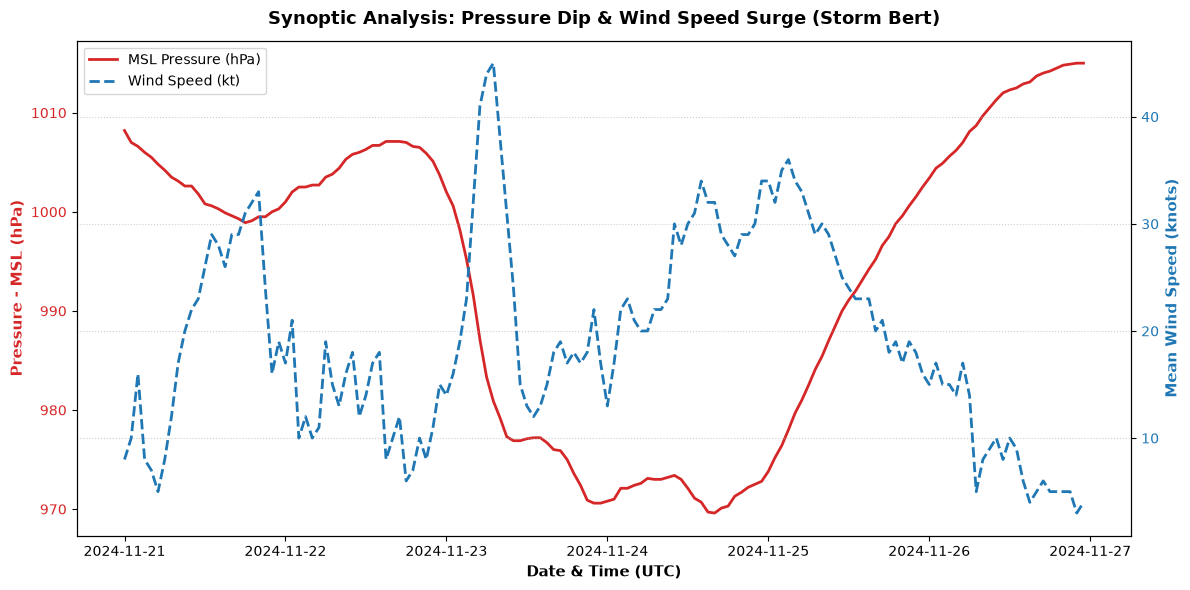

In [7]:
%pip install matplotlib

import matplotlib.pyplot as plt

# 1. Ensure numerical types for calculations
numeric_cols = ["temp", "dewpt", "rhum", "msl", "wdsp", "rain"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 2. Extract Key Meteorological Highlights during Storm Bert
min_msl_idx = df["msl"].idxmin()
max_wind_idx = df["wdsp"].idxmax()

print("==================================================")
print("             STORM BERT ANALYSIS SUMMARY          ")
print("==================================================")
print(
    f"Minimum Sea Level Pressure : {df.loc[min_msl_idx, 'msl']} hPa "
    f"at {df.loc[min_msl_idx, 'date']}"
)
print(
    f"Peak Mean Wind Speed       : {df.loc[max_wind_idx, 'wdsp']} knots "
    f"at {df.loc[max_wind_idx, 'date']}"
)
print(f"Total Accumulated Rainfall : {df['rain'].sum():.1f} mm")
print("==================================================\n")

# 3. Create a Publication-Quality Dual-Axis Synoptic Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Mean Sea Level Pressure (Left Axis)
color = "tab:red"
ax1.set_xlabel("Date & Time (UTC)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Pressure - MSL (hPa)", color=color, fontsize=11, fontweight="bold")
line1 = ax1.plot(
    df["date"], df["msl"], color=color, linewidth=2, label="MSL Pressure (hPa)"
)
ax1.tick_params(axis="y", labelcolor=color)

# Plot Mean Wind Speed (Right Axis)
ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel(
    "Mean Wind Speed (knots)", color=color, fontsize=11, fontweight="bold"
)
line2 = ax2.plot(
    df["date"],
    df["wdsp"],
    color=color,
    linewidth=2,
    linestyle="--",
    label="Wind Speed (kt)",
)
ax2.tick_params(axis="y", labelcolor=color)

# Combined Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title(
    "Synoptic Analysis: Pressure Dip & Wind Speed Surge (Storm Bert)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.grid(True, linestyle=":", alpha=0.6)
fig.tight_layout()
plt.show()

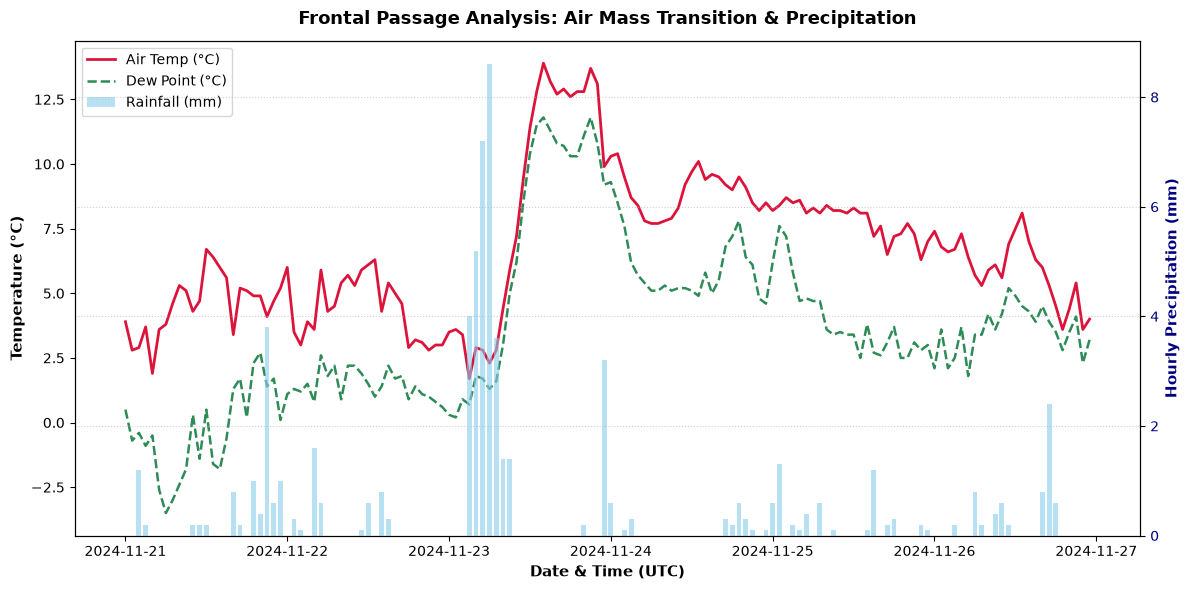

In [8]:
# Create Frontal Analysis Plot (Air Temperature vs Dew Point vs Rainfall)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Temperature and Dew Point on Left Axis
ax1.set_xlabel("Date & Time (UTC)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Temperature (°C)", color="black", fontsize=11, fontweight="bold")

line_temp = ax1.plot(
    df["date"], df["temp"], color="crimson", linewidth=2, label="Air Temp (°C)"
)
line_dew = ax1.plot(
    df["date"],
    df["dewpt"],
    color="seagreen",
    linewidth=1.8,
    linestyle="--",
    label="Dew Point (°C)",
)

ax1.tick_params(axis="y", labelcolor="black")

# Rainfall on Right Axis as Bars
ax2 = ax1.twinx()
ax2.set_ylabel(
    "Hourly Precipitation (mm)",
    color="navy",
    fontsize=11,
    fontweight="bold",
)
bars_rain = ax2.bar(
    df["date"],
    df["rain"],
    color="skyblue",
    alpha=0.6,
    width=0.03,
    label="Rainfall (mm)",
)
ax2.tick_params(axis="y", labelcolor="navy")

# Legend
lines = line_temp + line_dew + [bars_rain]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title(
    "Frontal Passage Analysis: Air Mass Transition & Precipitation",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.grid(True, linestyle=":", alpha=0.6)
fig.tight_layout()
plt.show()

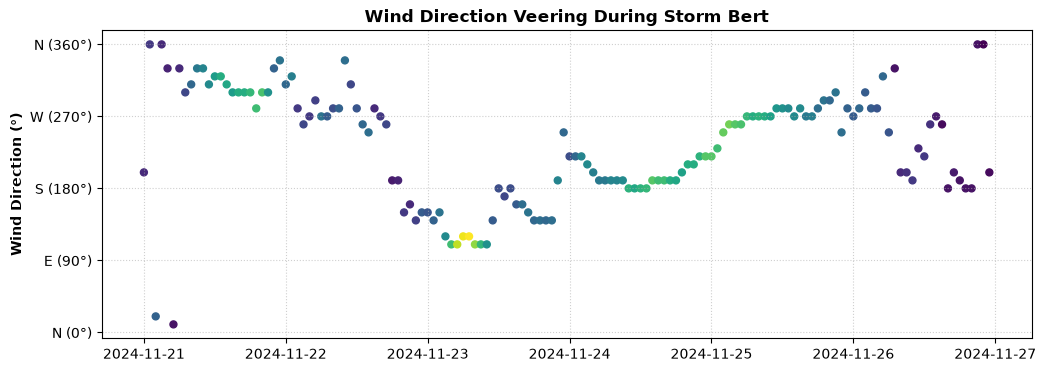

In [9]:
# Plotting Wind Direction Vector Shift
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(df["date"], df["wddir"], c=df["wdsp"], cmap="viridis", s=25)
ax.set_ylabel("Wind Direction (°)", fontweight="bold")
ax.set_yticks([0, 90, 180, 270, 360])
ax.set_yticklabels(["N (0°)", "E (90°)", "S (180°)", "W (270°)", "N (360°)"])
plt.title("Wind Direction Veering During Storm Bert", fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

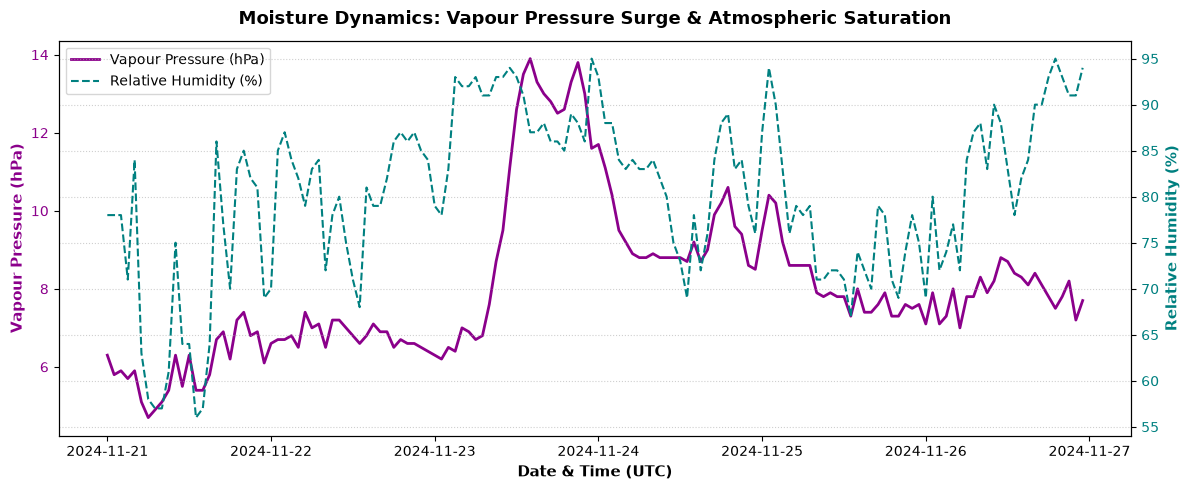

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot Vapour Pressure (Absolute Moisture Content)
color = "darkmagenta"
ax1.set_xlabel("Date & Time (UTC)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Vapour Pressure (hPa)", color=color, fontsize=11, fontweight="bold")
line1 = ax1.plot(df["date"], df["vappr"], color=color, linewidth=2, label="Vapour Pressure (hPa)")
ax1.tick_params(axis="y", labelcolor=color)

# Plot Relative Humidity on Secondary Axis
ax2 = ax1.twinx()
color = "teal"
ax2.set_ylabel("Relative Humidity (%)", color=color, fontsize=11, fontweight="bold")
line2 = ax2.plot(df["date"], df["rhum"], color=color, linewidth=1.5, linestyle="--", label="Relative Humidity (%)")
ax2.tick_params(axis="y", labelcolor=color)

# Combine Legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Moisture Dynamics: Vapour Pressure Surge & Atmospheric Saturation", fontsize=13, fontweight="bold", pad=12)
plt.grid(True, linestyle=":", alpha=0.6)
fig.tight_layout()
plt.show()

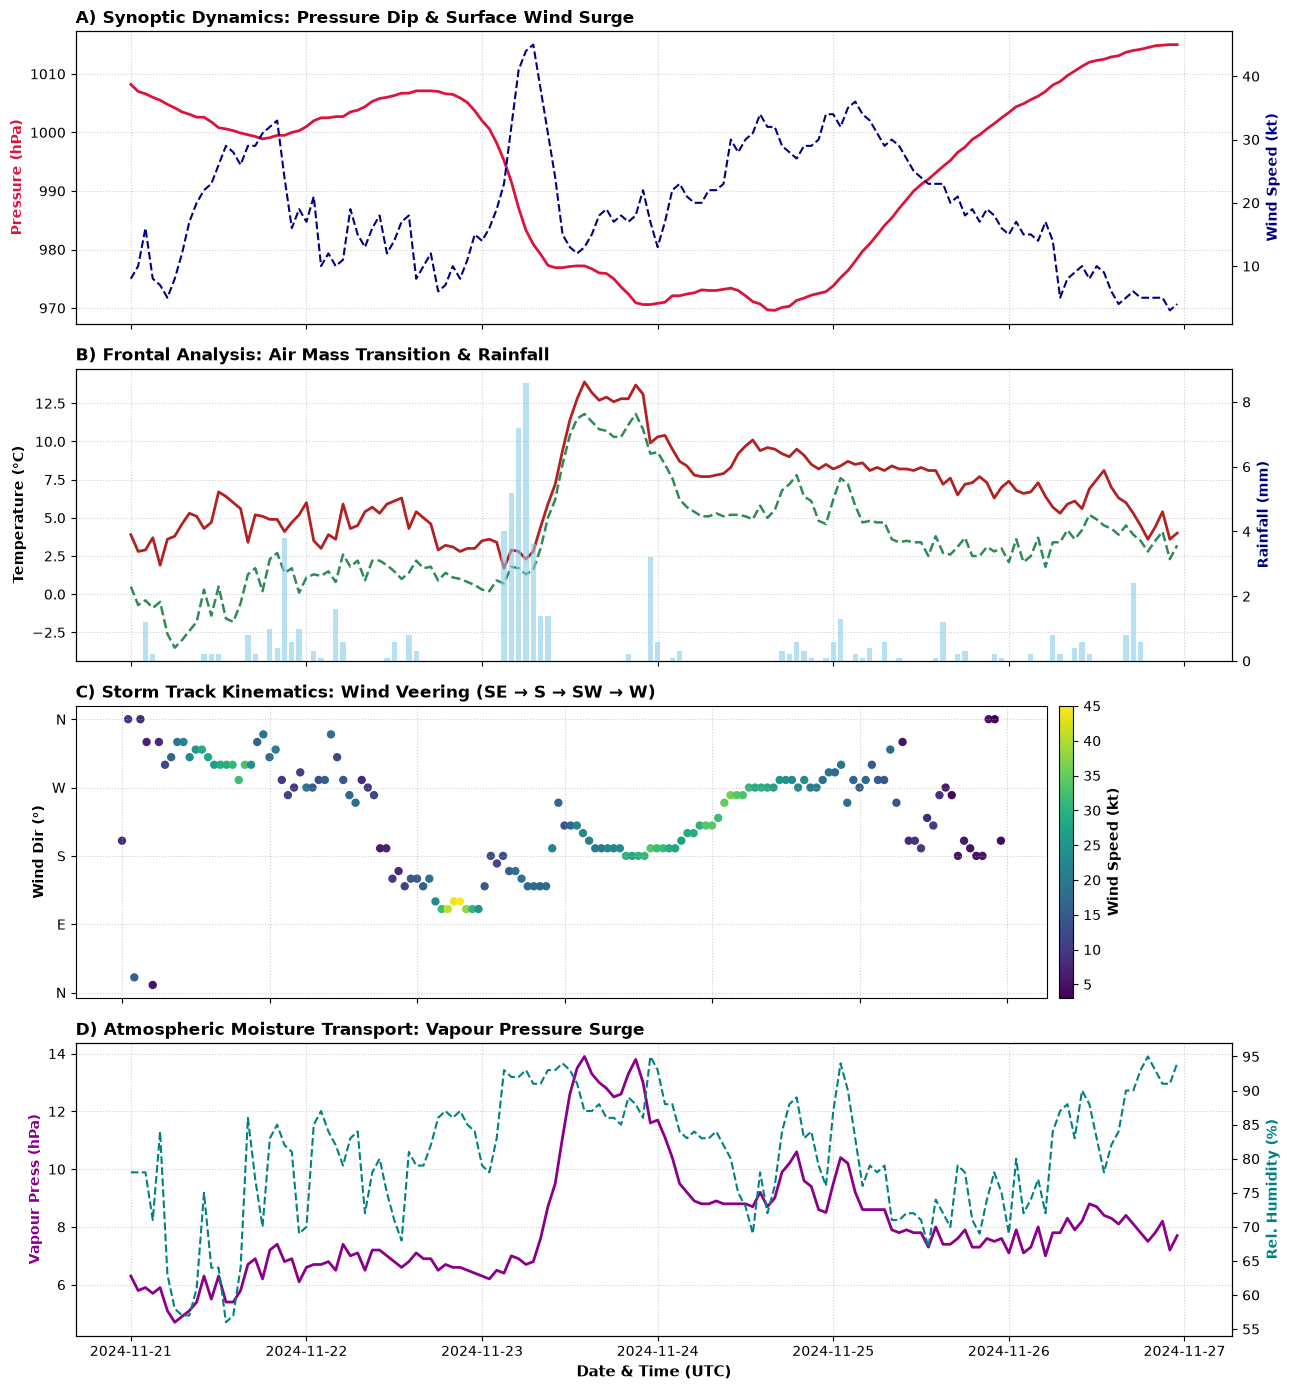

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(13, 14), sharex=True)

# Panel 1: Synoptic Pressure & Wind Speed
ax1_twin = axs[0].twinx()
p1 = axs[0].plot(df["date"], df["msl"], color="crimson", lw=2, label="MSL Pressure (hPa)")
p2 = ax1_twin.plot(df["date"], df["wdsp"], color="navy", lw=1.5, ls="--", label="Wind Speed (kt)")
axs[0].set_ylabel("Pressure (hPa)", color="crimson", fontweight="bold")
ax1_twin.set_ylabel("Wind Speed (kt)", color="navy", fontweight="bold")
axs[0].set_title("A) Synoptic Dynamics: Pressure Dip & Surface Wind Surge", fontweight="bold", loc="left")
axs[0].grid(True, ls=":", alpha=0.6)

# Panel 2: Frontal Thermodynamics & Rain
ax2_twin = axs[1].twinx()
p3 = axs[1].plot(df["date"], df["temp"], color="firebrick", lw=2, label="Air Temp (°C)")
p4 = axs[1].plot(df["date"], df["dewpt"], color="seagreen", lw=1.8, ls="--", label="Dew Point (°C)")
b1 = ax2_twin.bar(df["date"], df["rain"], color="skyblue", alpha=0.6, width=0.03, label="Rainfall (mm)")
axs[1].set_ylabel("Temperature (°C)", fontweight="bold")
ax2_twin.set_ylabel("Rainfall (mm)", color="navy", fontweight="bold")
axs[1].set_title("B) Frontal Analysis: Air Mass Transition & Rainfall", fontweight="bold", loc="left")
axs[1].grid(True, ls=":", alpha=0.6)

# Panel 3: Kinematic Veering (Wind Direction)
sc = axs[2].scatter(df["date"], df["wddir"], c=df["wdsp"], cmap="viridis", s=25)
axs[2].set_ylabel("Wind Dir (°)", fontweight="bold")
axs[2].set_yticks([0, 90, 180, 270, 360])
axs[2].set_yticklabels(["N", "E", "S", "W", "N"])
axs[2].set_title("C) Storm Track Kinematics: Wind Veering (SE → S → SW → W)", fontweight="bold", loc="left")
axs[2].grid(True, ls=":", alpha=0.6)
cbar = plt.colorbar(sc, ax=axs[2], pad=0.01)
cbar.set_label("Wind Speed (kt)", fontweight="bold")

# Panel 4: Moisture Flux (Vapour Pressure & Saturation)
ax4_twin = axs[3].twinx()
p5 = axs[3].plot(df["date"], df["vappr"], color="darkmagenta", lw=2, label="Vapour Pressure (hPa)")
p6 = ax4_twin.plot(df["date"], df["rhum"], color="teal", lw=1.5, ls="--", label="Relative Humidity (%)")
axs[3].set_ylabel("Vapour Press (hPa)", color="darkmagenta", fontweight="bold")
ax4_twin.set_ylabel("Rel. Humidity (%)", color="teal", fontweight="bold")
axs[3].set_title("D) Atmospheric Moisture Transport: Vapour Pressure Surge", fontweight="bold", loc="left")
axs[3].set_xlabel("Date & Time (UTC)", fontweight="bold", fontsize=11)
axs[3].grid(True, ls=":", alpha=0.6)

plt.tight_layout()
plt.savefig("Storm_Bert_MaceHead_Analysis.png", dpi=300, bbox_inches="tight")
plt.show()